**Лабораторная работа №13**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy. В первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [4]:
data = pd.read_csv('gbm-data.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (750, 1776)
Тестовая выборка: (3001, 1776)


2. Обучите GradientBoostingClassifier с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:

• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.

• Преобразуйте полученное предсказание по формуле.

• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.


In [5]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
n_estimators = 250

results = {}

for lr in learning_rates:
    print(f"\nОбучаем с learning_rate = {lr}")
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=lr,
        random_state=241,
        verbose=True
    )
    model.fit(X_train, y_train)

    train_loss = []
    test_loss = []

    for pred_train, pred_test in zip(
        model.staged_decision_function(X_train),
        model.staged_decision_function(X_test)
    ):
        prob_train = 1.0 / (1.0 + np.exp(-pred_train))
        prob_test  = 1.0 / (1.0 + np.exp(-pred_test))

        train_loss.append(log_loss(y_train, prob_train))
        test_loss.append(log_loss(y_test, prob_test))

    test_loss = np.array(test_loss)
    best_iter = np.argmin(test_loss) + 1
    best_loss = test_loss[best_iter - 1]

    results[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'best_iter': best_iter,
        'best_loss': best_loss
    }

    print(f"  Лучший log-loss на тесте: {best_loss:.4f} на итерации {best_iter}")


Обучаем с learning_rate = 1
      Iter       Train Loss   Remaining Time 
         1           1.0190           17.37s
         2           0.9192           17.36s
         3           0.8272           17.94s
         4           0.7834           17.85s
         5           0.7109           17.74s
         6           0.6368           17.79s
         7           0.5797           17.77s
         8           0.5610           17.75s
         9           0.5185           17.73s
        10           0.4984           17.92s
        20           0.1999           16.62s
        30           0.1313           16.64s
        40           0.0790           17.64s
        50           0.0511           17.77s
        60           0.0352           17.25s
        70           0.0245           15.85s
        80           0.0162           14.60s
        90           0.0114           13.48s
       100           0.0077           12.47s
       200           0.0002            3.87s
  Лучший log-loss на тест

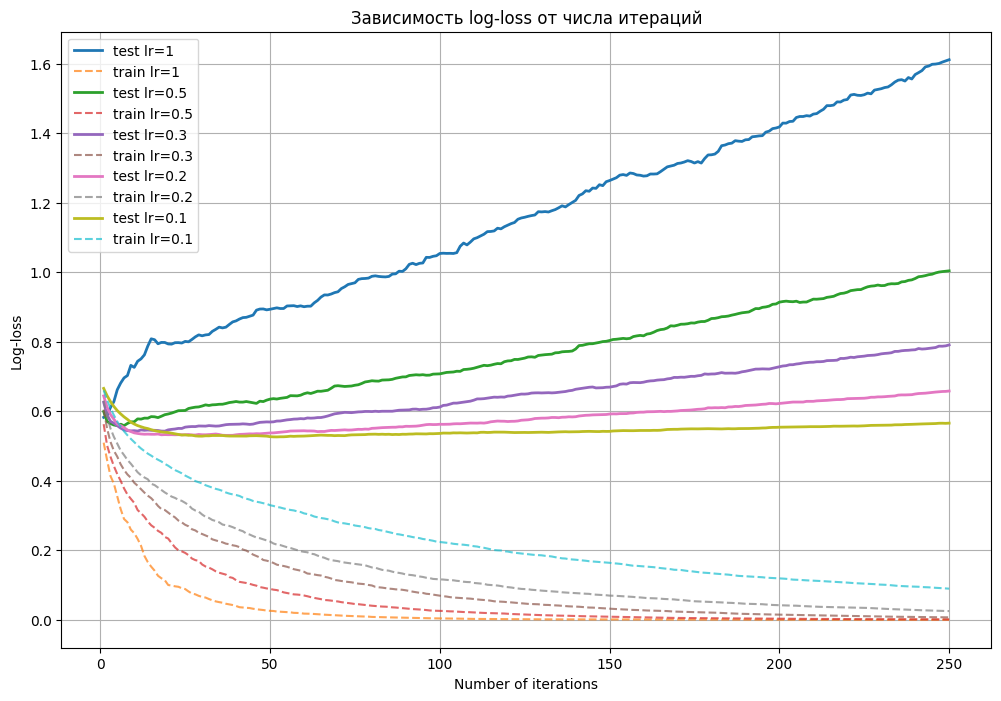

In [6]:
plt.figure(figsize=(12, 8))

for lr, res in results.items():
    plt.plot(range(1, n_estimators+1), res['test_loss'],
             label=f'test lr={lr}', linewidth=2)
    plt.plot(range(1, n_estimators+1), res['train_loss'],
             '--', label=f'train lr={lr}', alpha=0.7)

plt.xlabel('Number of iterations')
plt.ylabel('Log-loss')
plt.title('Зависимость log-loss от числа итераций')
plt.legend()
plt.grid(True)
plt.show()

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)? В ответе укажите одно из слов overfitting либо underfitting.

*По графику видно, что тестовый log-loss растет, а обучающий падает – это **overfitting**.*

In [7]:
answer1 = "overfitting"
print(answer1)

with open('answer1.txt', 'w') as f:
    f.write(answer1)

overfitting


4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [8]:
lr_target = 0.2
best_iter = results[lr_target]['best_iter']
best_loss = results[lr_target]['best_loss']

best_loss_rounded = round(best_loss, 2)

answer2 = f"{best_loss_rounded} {best_iter}"
print(answer2)

with open('answer2.txt', 'w') as f:
    f.write(answer2)

0.53 37


5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [10]:
rf = RandomForestClassifier(n_estimators=best_iter, random_state=241)
rf.fit(X_train, y_train)

proba_test = rf.predict_proba(X_test)[:, 1]

rf_log_loss = log_loss(y_test, proba_test)
rf_log_loss_rounded = round(rf_log_loss, 2)

print(f"Log-loss случайного леса: {rf_log_loss:.4f} -> {rf_log_loss_rounded}")

answer3 = str(rf_log_loss_rounded)
print(answer3)

with open('answer3.txt', 'w') as f:
    f.write(answer3)

Log-loss случайного леса: 0.5411 -> 0.54
0.54


In [12]:
for i, ans in enumerate([answer1, answer2, answer3], 1):
    with open(f'answer{i}.txt', 'r') as f:
        content = f.read()
    print(f"answer{i}.txt: '{content}'")

answer1.txt: 'overfitting'
answer2.txt: '0.53 37'
answer3.txt: '0.54'
